# The Hurst Exponent (H)

The Hurst exponent is a single number between 0 and 1 that captures the **long-range memory** of a time series.
It answers: is this series **trending**, **mean-reverting**, or behaving like **pure noise**?

## Notebook Structure

1. Historical background and interpretation
2. Rescaled Range (R/S) Analysis — the classical method
3. Fractional Brownian Motion (fBm)
4. Rolling Hurst — dynamic regime detection
5. Detrended Fluctuation Analysis (DFA)
6. Application to real market data
7. Generalized Hurst Exponent (GHE)
8. Limitations, pitfalls and significance testing
9. Trading applications

## Interpretation Table

| H Range | Behavior | Strategy | Financial Example |
|---------|----------|----------|------------------|
| 0.0-0.4 | Strongly anti-persistent | Aggressive mean-reversion | Bid-ask spreads |
| 0.4-0.5 | Weakly anti-persistent | Mild mean-reversion | Interest rate differentials |
| 0.5 | Random walk | No edge | EMH-efficient assets |
| 0.5-0.7 | Weakly persistent | Mild momentum | Equity indices |
| 0.7-1.0 | Strongly persistent | Strong trend-following | Volatility, commodities, crypto |

In [ ]:
# ==============================================================
#  IMPORTS
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Estilo global dos plots
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

SEED = 42
np.random.seed(SEED)

print('Setup completo.')

Setup completo.


---
## 1. Historical Background

### 1.1 The Nile River Problem (Harold Edwin Hurst, 1951)
Harold Hurst was a British hydrologist studying the flooding patterns of the Nile River.
His practical problem: **how large should a reservoir be** to handle unpredictable flooding?

If water levels were purely random, standard statistical formulas would suffice.
But Hurst discovered something remarkable:

> *High-water years tended to cluster together, as did low-water years — far more than pure randomness would predict.*

He quantified this through the **Rescaled Range (R/S)** statistic, and the scaling exponent he derived became the **Hurst Exponent (H)**.

### 1.2 Mandelbrot's Extension (1960s-1970s)
Benoit Mandelbrot — the father of fractal geometry — connected H to **Fractional Brownian Motion (fBm)**:
- **Standard Brownian motion**: independent increments (H = 0.5)
- **fBm**: increments can be *correlated* — a generalization that incorporates memory
- In financial markets: asset returns exhibit *long memory* and fat tails, violating the Efficient Market Hypothesis

### 1.3 Mandelbrot's Two Effects

| Effect | Biblical Name | Description |
|--------|--------------|-------------|
| Long memory | **Joseph Effect** | 7 years of plenty followed by 7 of famine — long-range dependence (H > 0.5) |
| Fat tails | **Noah Effect** | The Flood — extreme jumps far more likely than Gaussian models predict |

### 1.4 Mathematical Interpretation

**H = 0.5 — Random Walk**
$$\text{Cov}(X_t, X_{t+k}) = 0 \quad \forall k \neq 0$$

**H > 0.5 — Persistent (Trend-Following)**

The autocorrelation function decays as a power law:
$$C(k) \sim k^{2H-2} \quad \text{as } k \to \infty$$

For H > 0.5, the exponent $2H - 2 > -1$ — correlations decay **slowly**, the signature of long memory.

**H < 0.5 — Anti-Persistent (Mean-Reverting)**

The series exhibits negative long-range autocorrelation — an upward move is more likely to be followed by a downward move.

---
## 2. Rescaled Range (R/S) Analysis — The Classical Method

Given a time series $\{X_1, X_2, \ldots, X_N\}$ divided into sub-series of length $n$:

**Step 1 — Mean:** $\bar{X}_n = \frac{1}{n} \sum_{i=1}^{n} X_i$

**Step 2 — Cumulative Deviation:** $Y_t = \sum_{i=1}^{t}(X_i - \bar{X}_n)$

**Step 3 — Range:** $R(n) = \max Y_t - \min Y_t$

**Step 4 — Std Dev:** $S(n) = \sqrt{\frac{1}{n} \sum_{i=1}^{n}(X_i - \bar{X}_n)^2}$

**Step 5 — Rescaled Range:** $\frac{R(n)}{S(n)}$

**Step 6 — Scaling Law:**
$$\frac{R(n)}{S(n)} \sim C \cdot n^H$$

Taking logarithms:
$$\log\left(\frac{R}{S}\right) = H \cdot \log(n) + \log(C)$$

So **H is the slope** of the log-log plot of R/S vs n.

### Anis-Lloyd Correction (1976)
For small samples, R/S overestimates H. The expected value for a random walk is:
$$\mathbb{E}\left[\frac{R(n)}{S(n)}\right] = \frac{\Gamma\left(\frac{n-1}{2}\right)}{\sqrt{\pi} \cdot \Gamma\left(\frac{n}{2}\right)} \cdot \sum_{i=1}^{n-1}\sqrt{\frac{n-i}{i}}$$

In [ ]:
# ==============================================================
#  R/S ANALYSIS — IMPLEMENTATION FROM SCRATCH
# ==============================================================

def compute_rs_for_window(series):
    """R/S statistic for a single window."""
    mean = np.mean(series)
    cumulative_dev = np.cumsum(series - mean)
    R = np.max(cumulative_dev) - np.min(cumulative_dev)
    S = np.std(series, ddof=0)
    return R / S if S > 0 else np.nan


def rs_analysis(series, min_window=10, max_window=None, num_points=30):
    """
    Full R/S analysis over multiple window sizes.
    Returns log_n, log_rs, and estimated H (slope of log-log fit).
    """
    N = len(series)
    if max_window is None:
        max_window = N // 2

    # Log-spaced window sizes
    window_sizes = np.unique(
        np.logspace(np.log10(min_window), np.log10(max_window), num_points).astype(int)
    )

    log_n_list, log_rs_list = [], []

    for n in window_sizes:
        num_sub = N // n
        if num_sub == 0:
            continue

        # Compute R/S for each non-overlapping sub-window, drop NaNs
        rs_vals = [compute_rs_for_window(series[i*n:(i+1)*n]) for i in range(num_sub)]
        rs_vals = [v for v in rs_vals if not np.isnan(v)]

        if rs_vals:
            log_n_list.append(np.log(n))
            log_rs_list.append(np.log(np.mean(rs_vals)))

    log_n = np.array(log_n_list)
    log_rs = np.array(log_rs_list)

    # H = slope of log-log regression
    H = np.polyfit(log_n, log_rs, 1)[0]

    return log_n, log_rs, H


print('R/S analysis functions defined.')

R/S analysis functions defined.


---
## 3. Generating Synthetic Fractional Brownian Motion (fBm)

We generate **fractional Gaussian noise (fGn)** using the **Cholesky decomposition**
of the autocovariance matrix, then cumulate to get fBm.

The autocovariance of fGn at lag $k$:
$$\gamma(k) = \frac{\sigma^2}{2}\left(|k-1|^{2H} - 2|k|^{2H} + |k+1|^{2H}\right)$$

This is exact but $O(n^2)$ — suitable for simulation, not production.

In [ ]:
# ==============================================================
#  FRACTIONAL BROWNIAN MOTION — CHOLESKY METHOD
# ==============================================================

def fgn_autocovariance(H, n):
    """Autocovariance of fractional Gaussian noise at lags 0..n-1."""
    k = np.arange(n)
    return 0.5 * (np.abs(k - 1)**(2*H) - 2*np.abs(k)**(2*H) + (k + 1)**(2*H))


def generate_fbm(H, n, seed=None):
    """
    Generate fBm path via Cholesky decomposition.
    Returns (fbm_path, fgn_increments).
    """
    if seed is not None:
        np.random.seed(seed)

    from scipy.linalg import toeplitz, cholesky

    gamma = fgn_autocovariance(H, n)
    L = cholesky(toeplitz(gamma), lower=True)
    fgn = L @ np.random.randn(n)

    return np.concatenate([[0], np.cumsum(fgn)]), fgn


# Generate paths for three regimes
N = 2000
H_values = [0.2, 0.5, 0.8]
series_dict = {}

for h in H_values:
    fbm_path, fgn_inc = generate_fbm(h, N, seed=SEED)
    series_dict[h] = {'fbm': fbm_path, 'fgn': fgn_inc}

print(f'Generated fBm paths with H = {H_values}, length = {N+1}')

Generated fBm paths with H = [0.2, 0.5, 0.8], length = 2001


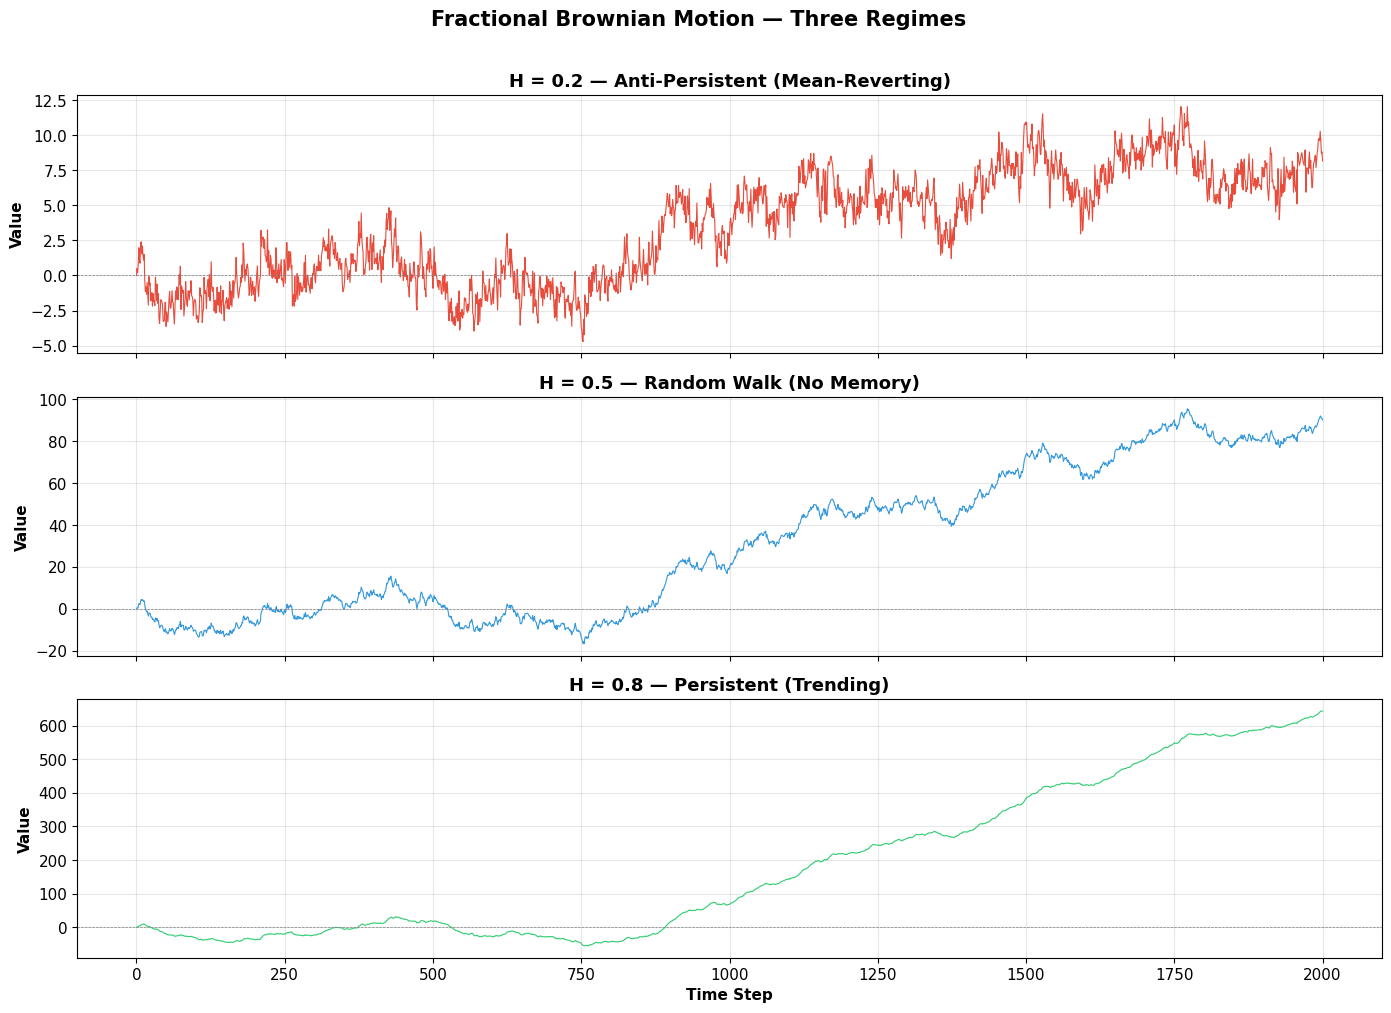

In [ ]:
# ==============================================================
#  VISUALIZING THE THREE REGIMES
# ==============================================================

colors = {0.2: '#e74c3c', 0.5: '#3498db', 0.8: '#2ecc71'}
labels = {
    0.2: 'Anti-Persistent (Mean-Reverting)',
    0.5: 'Random Walk (No Memory)',
    0.8: 'Persistent (Trending)'
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, h in zip(axes, H_values):
    ax.plot(series_dict[h]['fbm'], color=colors[h], linewidth=0.8)
    ax.set_title(f'H = {h} — {labels[h]}', fontsize=13)
    ax.set_ylabel('Value')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[-1].set_xlabel('Time Step')
fig.suptitle('Fractional Brownian Motion — Three Regimes', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. R/S Verification on Synthetic Data

We verify our implementation by estimating H from the fGn increments
(not the fBm path — increments are stationary, which R/S requires).

The log-log plot of R/S vs window size should yield a straight line
with slope ≈ H. A good implementation recovers the true H within ~0.1.


    True H |  Estimated H |      Error
       0.2 |       0.3099 |     0.1099
       0.5 |       0.5645 |     0.0645
       0.8 |       0.7863 |     0.0137


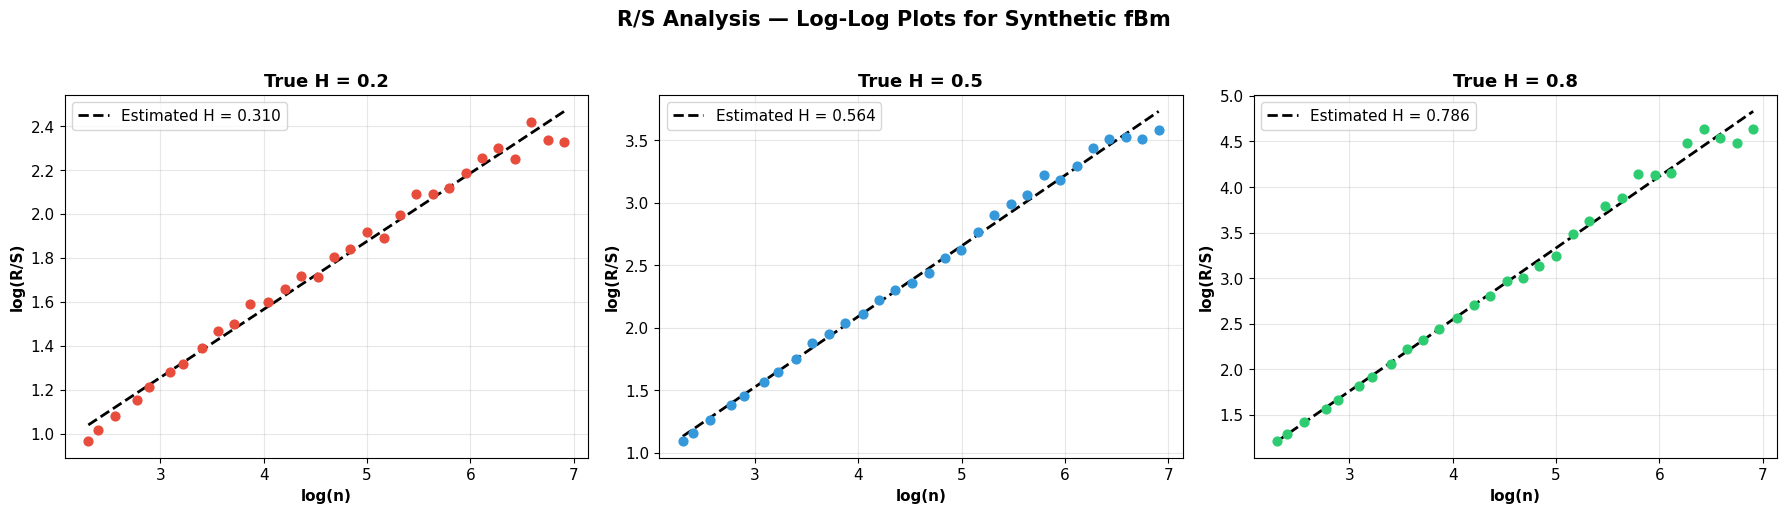

In [ ]:
# ==============================================================
#  R/S VERIFICATION ON SYNTHETIC fBm
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

print(f'\n{"True H":>10} | {"Estimated H":>12} | {"Error":>10}')
print('=' * 40)

for ax, h_true in zip(axes, H_values):
    # Use fGn increments (stationary) — not the fBm path
    log_n, log_rs, h_est = rs_analysis(series_dict[h_true]['fgn'])

    # Scatter + regression line
    ax.scatter(log_n, log_rs, color=colors[h_true], s=40, zorder=3)
    fit = np.polyval(np.polyfit(log_n, log_rs, 1), log_n)
    ax.plot(log_n, fit, 'k--', lw=2, label=f'Estimated H = {h_est:.3f}')

    ax.set_title(f'True H = {h_true}', fontsize=13)
    ax.set_xlabel('log(n)')
    ax.set_ylabel('log(R/S)')
    ax.legend(fontsize=11, loc='upper left')

    print(f'{h_true:>10.1f} | {h_est:>12.4f} | {abs(h_est - h_true):>10.4f}')

fig.suptitle('R/S Analysis — Log-Log Plots for Synthetic fBm',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Rolling Hurst Exponent

In practice, H is **not constant** over time. Markets shift between
trending and mean-reverting regimes. A **rolling window** reveals these transitions.

> Using fGn increments in each window, not the cumulative fBm path.

| Rolling H | Signal | Action |
|-----------|--------|--------|
| H > 0.6 | Strong persistence | Trail trend-following stops |
| 0.5 < H < 0.6 | Mild persistence | Cautious momentum |
| H ≈ 0.5 | Random | Reduce position sizing |
| H < 0.4 | Strong anti-persistence | Aggressive mean-reversion |

In [ ]:
# ==============================================================
#  ROLLING HURST EXPONENT
# ==============================================================

def rolling_hurst(series, window=200, step=10):
    """
    Compute rolling H via R/S analysis.
    Returns indices (center of each window) and H values.
    """
    n = len(series)
    indices, h_values = [], []

    for start in range(0, n - window, step):
        try:
            _, _, h = rs_analysis(
                series[start:start + window],
                min_window=10,
                max_window=window // 2,
                num_points=15
            )
            indices.append(start + window // 2)
            h_values.append(h)
        except:
            pass

    return np.array(indices), np.array(h_values)


# Composite series: trending -> random -> mean-reverting
seg = 800
_, s1 = generate_fbm(0.8, seg, seed=10)   # trending
_, s2 = generate_fbm(0.5, seg, seed=20)   # random
_, s3 = generate_fbm(0.2, seg, seed=30)   # mean-reverting
composite = np.concatenate([s1, s2, s3])

idx, h_roll = rolling_hurst(composite, window=300, step=5)

print(f'Rolling Hurst computed: {len(h_roll)} observations')

Rolling Hurst computed: 420 observations


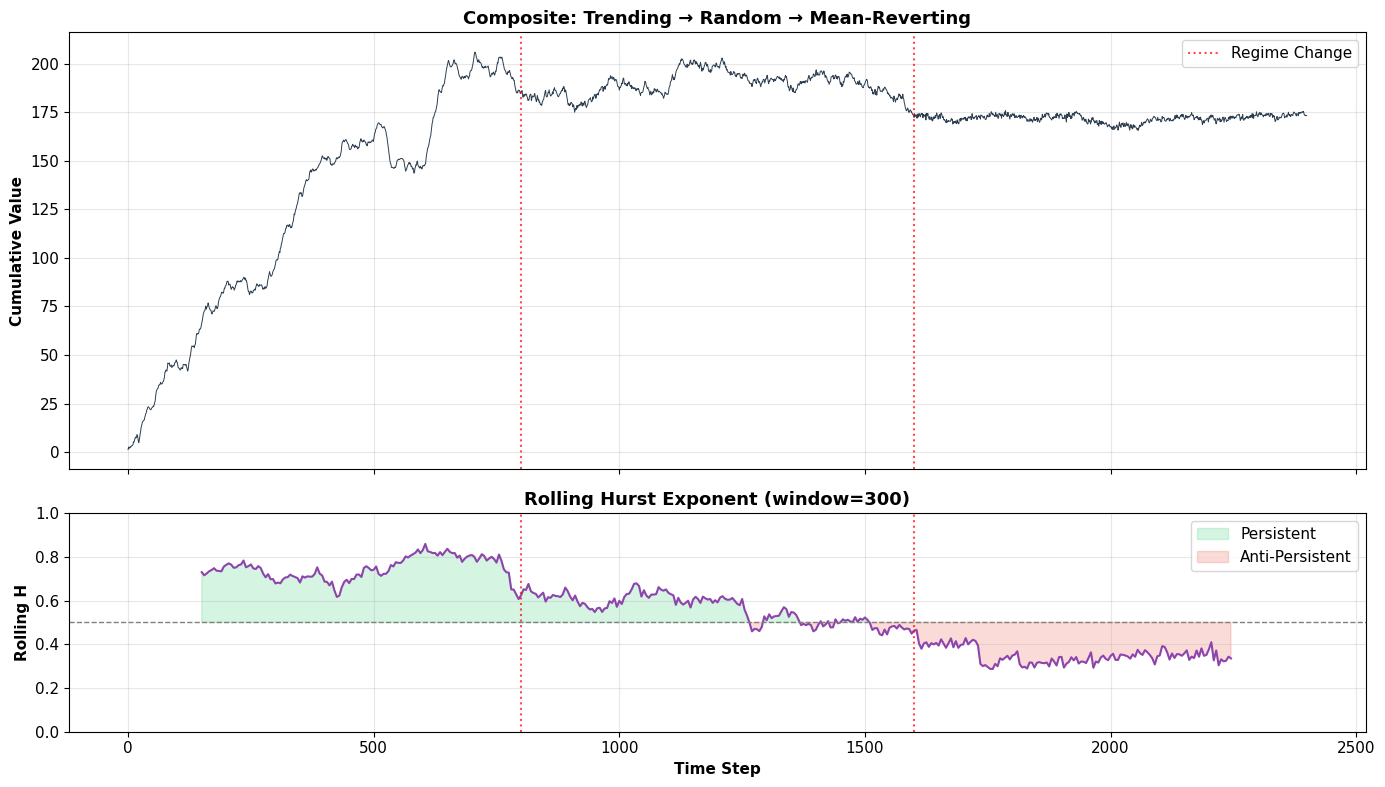

In [ ]:
# ==============================================================
#  ROLLING HURST — VISUALIZATION
# ==============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top: cumulative composite series
ax1.plot(np.cumsum(composite), color='#2c3e50', lw=0.7)
ax1.axvline(seg,   color='red', ls=':', alpha=0.7, label='Regime Change')
ax1.axvline(2*seg, color='red', ls=':', alpha=0.7)
ax1.set_title('Composite: Trending → Random → Mean-Reverting', fontsize=13)
ax1.set_ylabel('Cumulative Value')
ax1.legend()

# Bottom: rolling H
ax2.plot(idx, h_roll, color='#8e44ad', lw=1.5)
ax2.axhline(0.5, color='gray', ls='--', lw=1)
ax2.fill_between(idx, 0.5, h_roll, where=(h_roll > 0.5),
                 color='#2ecc71', alpha=0.2, label='Persistent')
ax2.fill_between(idx, 0.5, h_roll, where=(h_roll < 0.5),
                 color='#e74c3c', alpha=0.2, label='Anti-Persistent')
ax2.axvline(seg,   color='red', ls=':', alpha=0.7)
ax2.axvline(2*seg, color='red', ls=':', alpha=0.7)
ax2.set_ylabel('Rolling H')
ax2.set_xlabel('Time Step')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')
ax2.set_title('Rolling Hurst Exponent (window=300)', fontsize=13)

plt.tight_layout()
plt.show()

---
## 6. Detrended Fluctuation Analysis (DFA)

DFA is more robust than R/S for **non-stationary** series.

| Issue | R/S | DFA |
|-------|-----|-----|
| Trend sensitivity | High | Low — detrends each segment |
| Short-range correlations | Can bias H up | More robust |
| Non-stationarity | Assumes stationarity | Handles it |

### Algorithm

1. **Integrate**: $Y(k) = \sum_{i=1}^{k}(x_i - \bar{x})$
2. **Segment** into blocks of size $n$
3. **Detrend** each segment

In [ ]:
# ==============================================================
#  DETRENDED FLUCTUATION ANALYSIS (DFA-1)
# ==============================================================

def dfa(series, min_window=10, max_window=None, num_points=30, order=1):
    """
    DFA-1: detrend each segment with a linear polynomial.
    Returns log_n, log_F, and scaling exponent alpha (~H).
    """
    N = len(series)
    if max_window is None:
        max_window = N // 4

    # Integrated profile
    profile = np.cumsum(series - np.mean(series))

    seg_sizes = np.unique(
        np.logspace(np.log10(min_window), np.log10(max_window), num_points).astype(int)
    )

    log_n_list, log_F_list = [], []

    for n in seg_sizes:
        num_segs = N // n
        if num_segs < 1:
            continue

        rms_vals = []
        for s in range(num_segs):
            segment = profile[s*n:(s+1)*n]
            x = np.arange(n)
            # Detrend: subtract local polynomial fit
            trend = np.polyval(np.polyfit(x, segment, order), x)
            rms_vals.append(np.mean((segment - trend)**2))

        F = np.sqrt(np.mean(rms_vals))
        if F > 0:
            log_n_list.append(np.log(n))
            log_F_list.append(np.log(F))

    log_n = np.array(log_n_list)
    log_F = np.array(log_F_list)
    alpha = np.polyfit(log_n, log_F, 1)[0]

    return log_n, log_F, alpha


print('DFA function defined.')

DFA function defined.


In [ ]:
# ==============================================================
#  DFA VERIFICATION — R/S vs DFA COMPARISON
# ==============================================================

print('DFA Verification on Synthetic fGn:')
print('=' * 50)
print(f'{"True H":>10} | {"DFA α":>10} | {"R/S H":>10}')
print('=' * 50)

for h in H_values:
    _, _, a   = dfa(series_dict[h]['fgn'])
    _, _, h_rs = rs_analysis(series_dict[h]['fgn'])
    print(f'{h:>10.1f} | {a:>10.4f} | {h_rs:>10.4f}')

DFA Verification on Synthetic fGn:
    True H |      DFA α |      R/S H
       0.2 |     0.2061 |     0.3099
       0.5 |     0.5064 |     0.5645
       0.8 |     0.8094 |     0.7863


---
## 7. Hurst Exponent on Real Market Data

We apply both estimators to real assets and answer:

1. Is the S&P 500 trending, random, or mean-reverting?
2. How does the regime evolve over time?
3. Do different assets exhibit different memory structures?

> **Important**: we always compute H on **returns** (pct_change),
> not prices — prices are non-stationary and would bias H toward 1.

In [ ]:
# ==============================================================
#  MARKET DATA — DOWNLOAD VIA YFINANCE
# ==============================================================

# Install if needed (Colab)
# !pip install yfinance -q

import yfinance as yf

tickers = {
    'SPY': 'S&P 500 ETF',
    'GLD': 'Gold ETF',
    'TLT': '20Y Treasury ETF',
    'BTC-USD': 'Bitcoin'
}

market_data = {}

for ticker, name in tickers.items():
    df = yf.download(ticker, start='2015-01-01', end='2025-01-01',
                     progress=False, auto_adjust=True)
    if len(df) > 0:
        close = df['Close'].squeeze()
        returns = close.pct_change().dropna().values
        market_data[ticker] = {
            'name': name,
            'close': close.values,
            'returns': returns,
            'dates': close.index
        }
        print(f'{name:>25} ({ticker}): {len(returns)} daily returns')

print('\nDownload complete.')

              S&P 500 ETF (SPY): 2515 daily returns
                 Gold ETF (GLD): 2515 daily returns
         20Y Treasury ETF (TLT): 2515 daily returns
                  Bitcoin (BTC-USD): 3652 daily returns

Download complete.


In [ ]:
# ==============================================================
#  GLOBAL HURST ESTIMATES — R/S vs DFA
# ==============================================================

print('Global Hurst Exponent Estimates')
print('=' * 65)
print(f'{"Asset":>25} | {"R/S H":>8} | {"DFA α":>8} | Regime')
print('=' * 65)

for ticker, data in market_data.items():
    _, _, h_rs = rs_analysis(data['returns'])
    _, _, a_dfa = dfa(data['returns'])
    regime = ('Persistent' if h_rs > 0.55
              else 'Anti-Persistent' if h_rs < 0.45
              else 'Random')
    print(f'{data["name"]:>25} | {h_rs:>8.4f} | {a_dfa:>8.4f} | {regime}')

Global Hurst Exponent Estimates
                    Asset |    R/S H |    DFA α | Regime
              S&P 500 ETF |   0.5344 |   0.4379 | Random
                 Gold ETF |   0.5489 |   0.4856 | Random
         20Y Treasury ETF |   0.5438 |   0.5024 | Random
                  Bitcoin |   0.6022 |   0.5670 | Persistent


---
## 8. Rolling Hurst on Market Data

Computing rolling H (252-day window) for each asset reveals
how memory structure evolves over time.

Key observations to look for:
- SPY: mostly near 0.5 with occasional persistent spikes (momentum regimes)
- GLD: tends to show higher persistence (commodity trend-following)
- TLT: regime shifts aligned with rate cycle changes
- BTC: consistently higher H — structural trend-following behavior

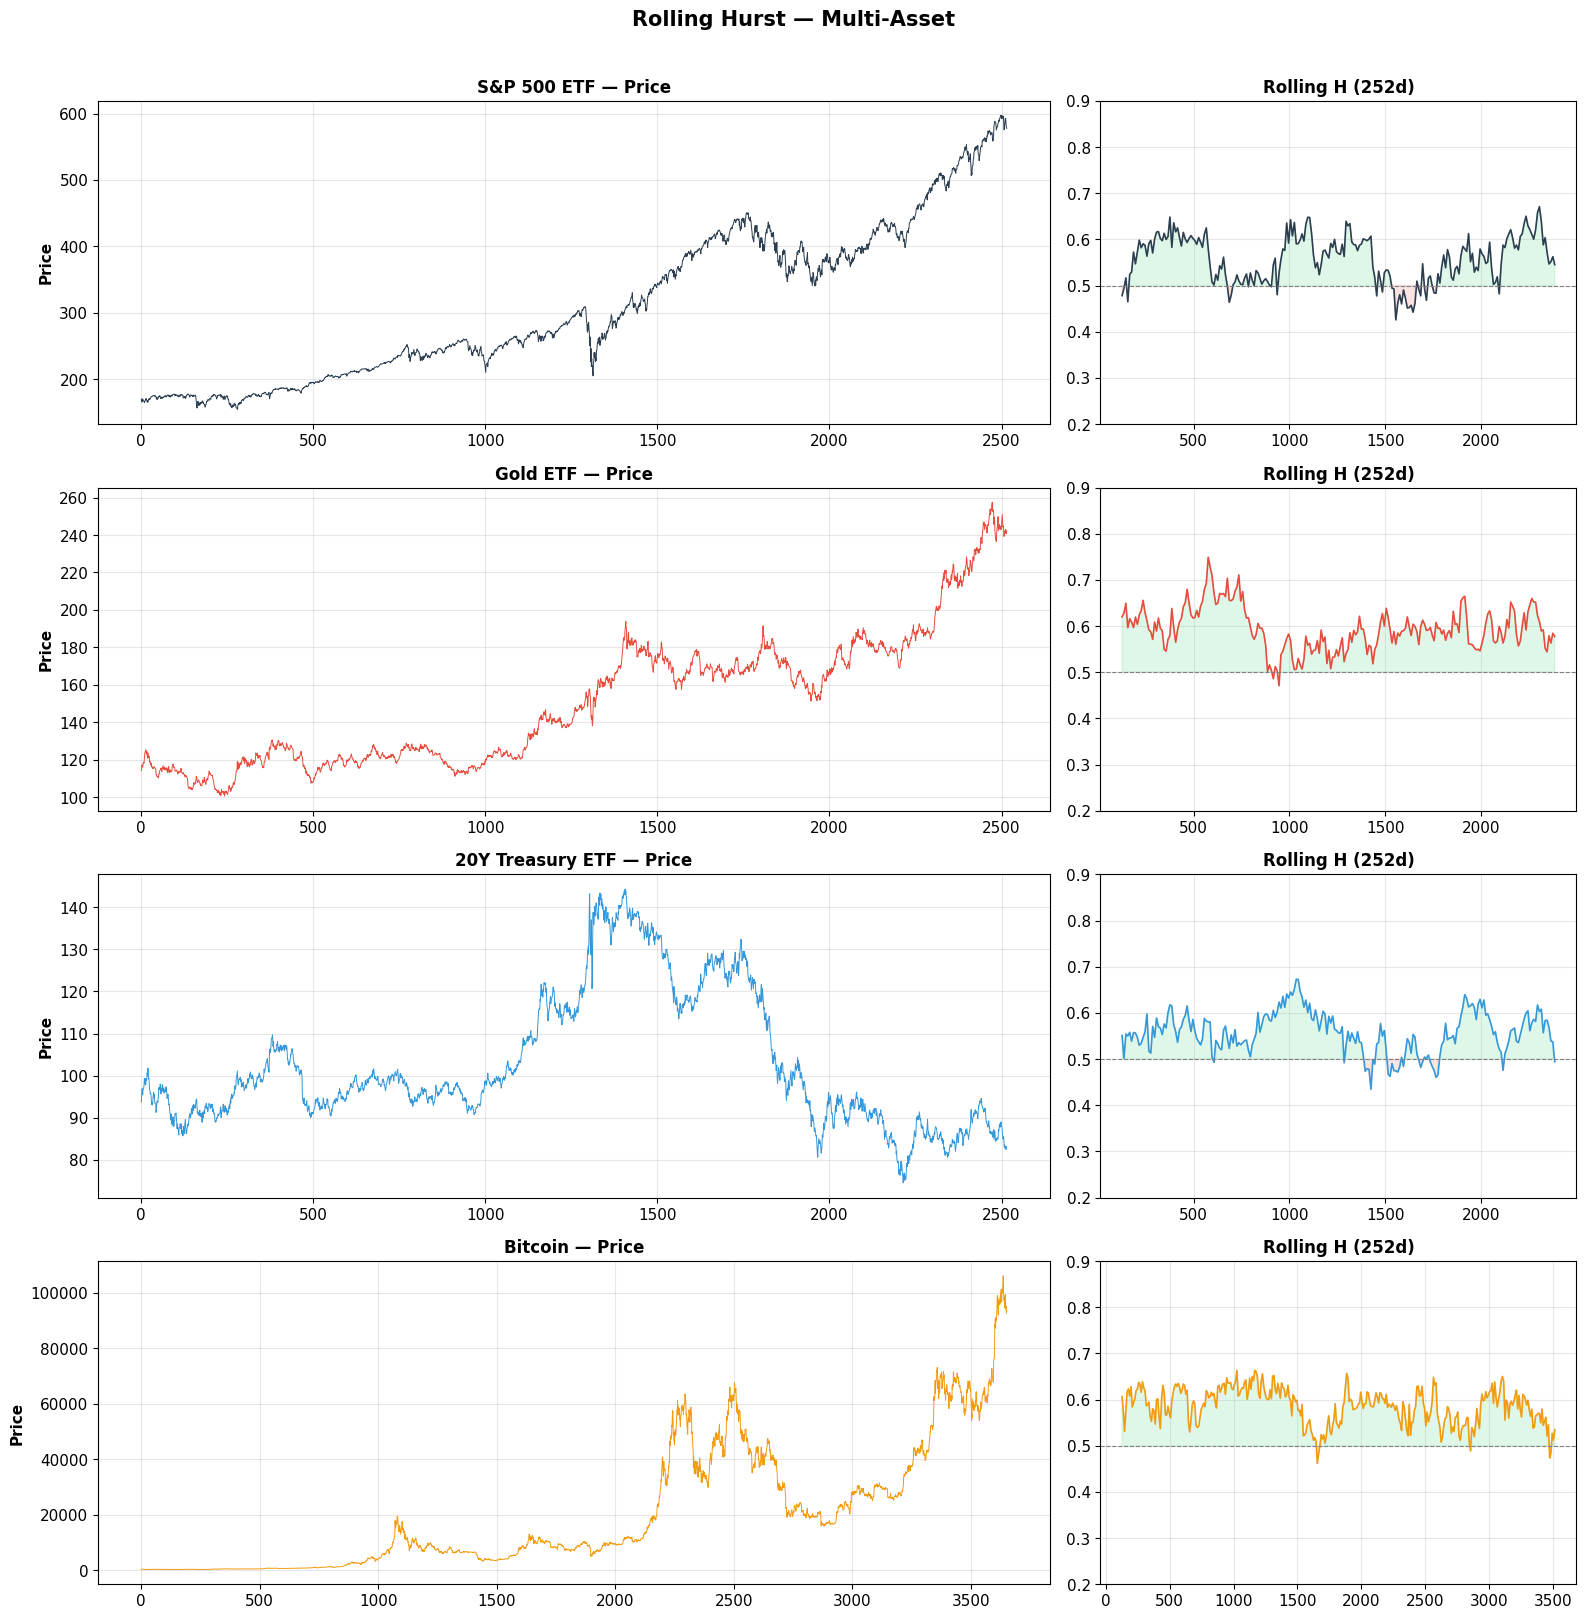

In [ ]:
# ==============================================================
#  ROLLING HURST — MULTI-ASSET
# ==============================================================

palette = ['#2c3e50', '#e74c3c', '#3498db', '#f39c12']

fig, axes = plt.subplots(len(market_data), 2,
                         figsize=(16, 4 * len(market_data)),
                         gridspec_kw={'width_ratios': [2, 1]})

for i, (ticker, data) in enumerate(market_data.items()):
    idx, h_vals = rolling_hurst(data['returns'], window=252, step=10)

    # Left: price
    axes[i, 0].plot(data['close'], color=palette[i], lw=0.7)
    axes[i, 0].set_title(f"{data['name']} — Price", fontsize=12)
    axes[i, 0].set_ylabel('Price')

    # Right: rolling H
    axes[i, 1].plot(idx, h_vals, color=palette[i], lw=1.2)
    axes[i, 1].axhline(0.5, color='gray', ls='--', lw=0.8)
    axes[i, 1].fill_between(idx, 0.5, h_vals,
                             where=(h_vals > 0.5),
                             color='#2ecc71', alpha=0.15)
    axes[i, 1].fill_between(idx, 0.5, h_vals,
                             where=(h_vals < 0.5),
                             color='#e74c3c', alpha=0.15)
    axes[i, 1].set_ylim(0.2, 0.9)
    axes[i, 1].set_title('Rolling H (252d)', fontsize=12)

fig.suptitle('Rolling Hurst — Multi-Asset',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Log-Log Diagnostic Plots

The quality of the linear fit in the log-log plot tells us how well
the power-law assumption holds.

- A **good fit** (R² close to 1) validates the H estimate
- A **poor fit** suggests the series is not self-similar,
  or that H is unstable across scales

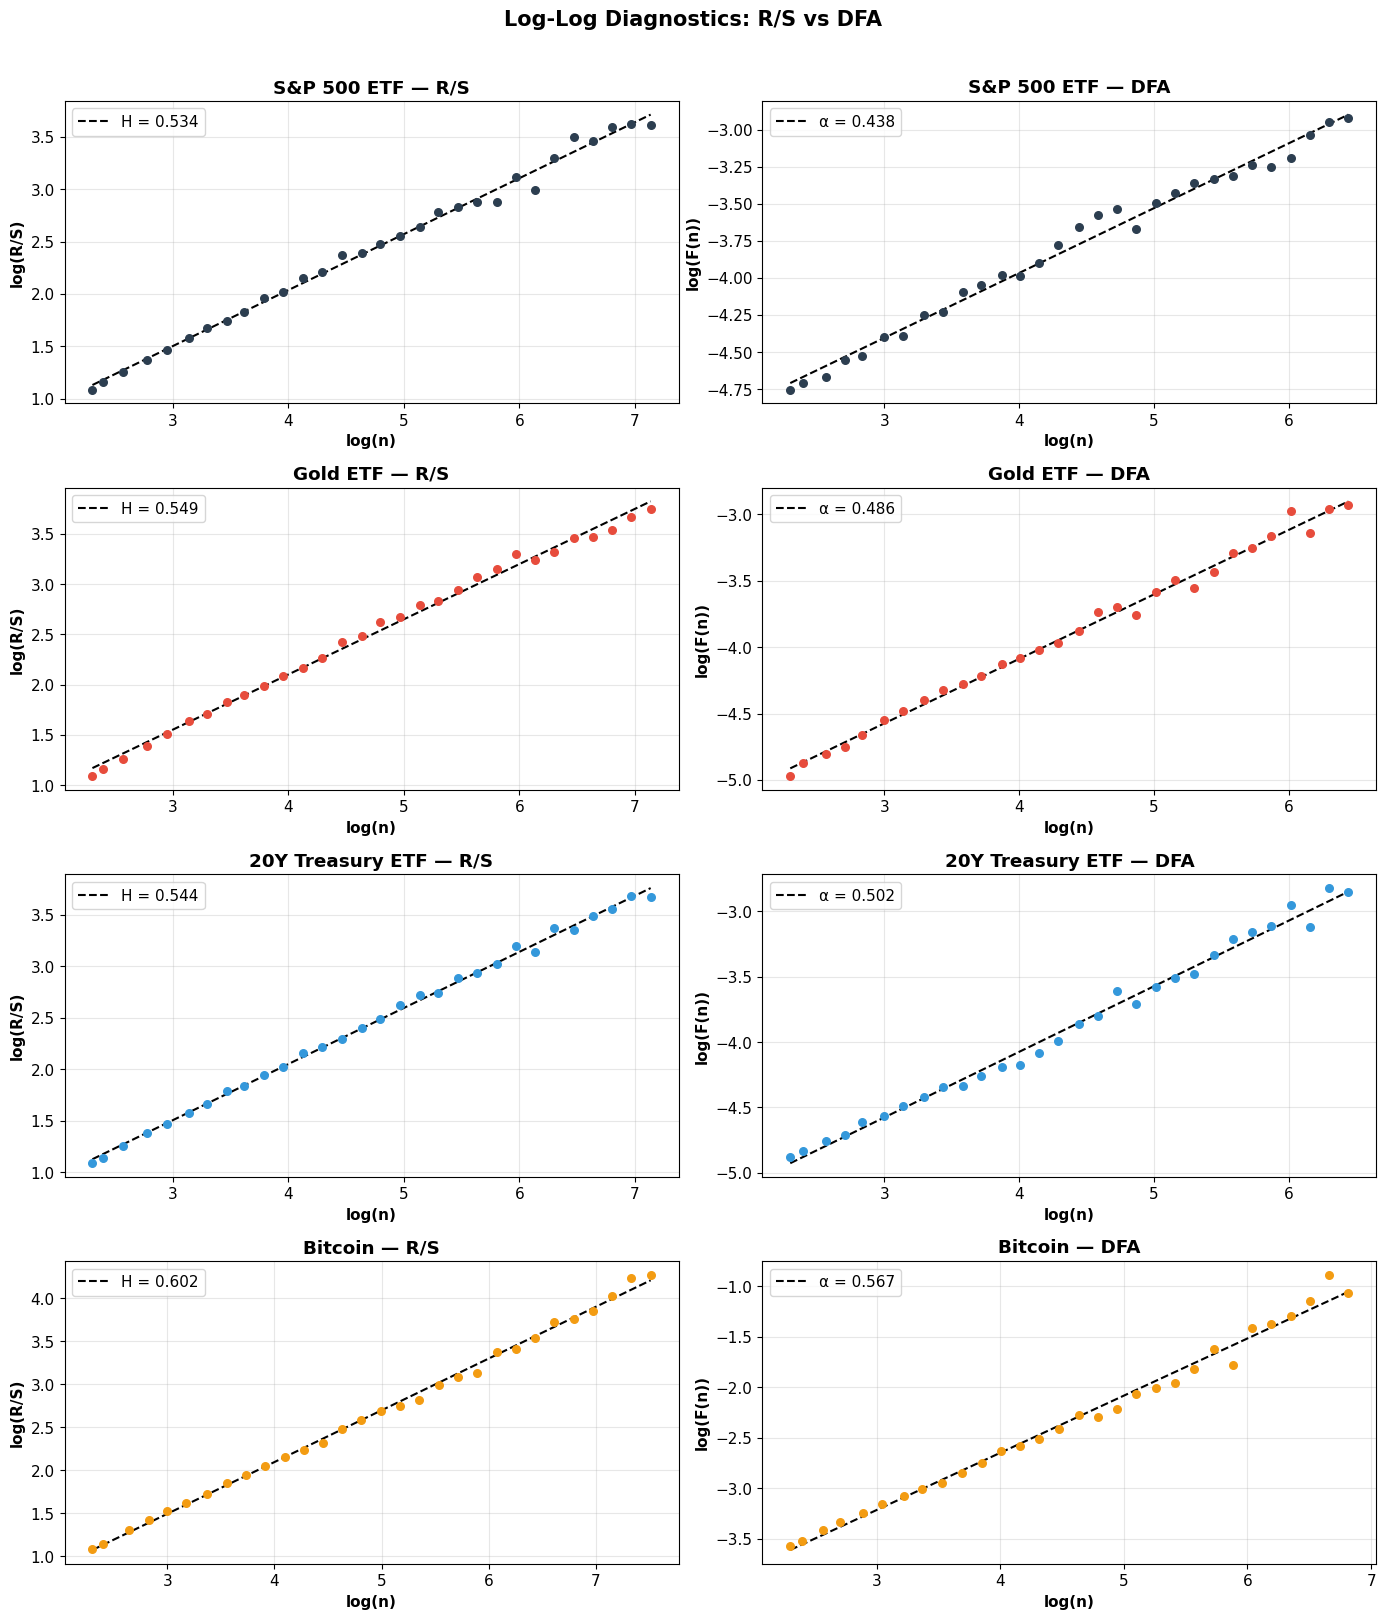

In [ ]:
# ==============================================================
#  LOG-LOG DIAGNOSTIC PLOTS — R/S vs DFA
# ==============================================================

fig, axes = plt.subplots(len(market_data), 2,
                         figsize=(14, 4 * len(market_data)))

for i, (ticker, data) in enumerate(market_data.items()):
    ret = data['returns']

    # R/S
    ln_rs, lrs, h = rs_analysis(ret)
    axes[i, 0].scatter(ln_rs, lrs, color=palette[i], s=30, zorder=3)
    axes[i, 0].plot(ln_rs, np.polyval(np.polyfit(ln_rs, lrs, 1), ln_rs),
                    'k--', lw=1.5, label=f'H = {h:.3f}')
    axes[i, 0].set_title(f"{data['name']} — R/S")
    axes[i, 0].set_xlabel('log(n)')
    axes[i, 0].set_ylabel('log(R/S)')
    axes[i, 0].legend()

    # DFA
    ln_d, lF, a = dfa(ret)
    axes[i, 1].scatter(ln_d, lF, color=palette[i], s=30, zorder=3)
    axes[i, 1].plot(ln_d, np.polyval(np.polyfit(ln_d, lF, 1), ln_d),
                    'k--', lw=1.5, label=f'α = {a:.3f}')
    axes[i, 1].set_title(f"{data['name']} — DFA")
    axes[i, 1].set_xlabel('log(n)')
    axes[i, 1].set_ylabel('log(F(n))')
    axes[i, 1].legend()

fig.suptitle('Log-Log Diagnostics: R/S vs DFA',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Generalized Hurst Exponent (GHE)

The standard H captures **second-order moments** only.
The GHE extends to arbitrary moment orders $q$:

$$\langle |X(t + \tau) - X(t)|^q \rangle \sim \tau^{q \cdot H(q)}$$

- If $H(q)$ is **constant** for all $q$: **monofractal**
- If $H(q)$ **varies** with $q$: **multifractal**

Financial data is often **multifractal** because small and large
price movements scale differently — a key violation of simple random walk models.

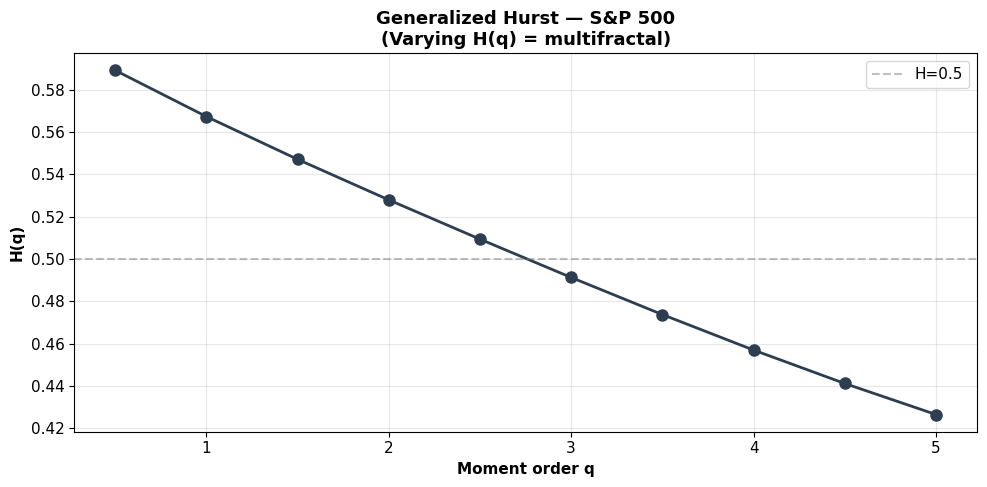

H(q) range: [0.4264, 0.5892], Spread: 0.1628
Multifractal


In [ ]:
# ==============================================================
#  GENERALIZED HURST EXPONENT (GHE)
# ==============================================================

def generalized_hurst(series, q_values, lags=None):
    """H(q) for various moment orders. Constant H(q) = monofractal."""
    if lags is None:
        lags = np.unique(np.logspace(0.5, 2.5, 30).astype(int))

    H_q = []
    for q in q_values:
        ll, lm = [], []
        for lag in lags:
            if lag >= len(series):
                continue
            diffs = np.abs(series[lag:] - series[:-lag])
            # Geometric mean for q=0, else standard moment
            moment = (np.exp(np.mean(np.log(diffs[diffs > 0])))
                      if q == 0
                      else np.mean(diffs**q)**(1.0/q))
            if moment > 0:
                ll.append(np.log(lag))
                lm.append(np.log(moment))
        H_q.append(np.polyfit(ll, lm, 1)[0] if len(ll) > 2 else np.nan)

    return np.array(q_values), np.array(H_q)


# Apply to SPY
if 'SPY' in market_data:
    q_range = np.arange(0.5, 5.5, 0.5)
    q_vals, H_q = generalized_hurst(market_data['SPY']['close'], q_range)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(q_vals, H_q, 'o-', color='#2c3e50', ms=8, lw=2)
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='H=0.5')
    ax.set_xlabel('Moment order q')
    ax.set_ylabel('H(q)')
    ax.set_title('Generalized Hurst — S&P 500\n(Varying H(q) = multifractal)', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

    spread = np.nanmax(H_q) - np.nanmin(H_q)
    print(f'H(q) range: [{np.nanmin(H_q):.4f}, {np.nanmax(H_q):.4f}], Spread: {spread:.4f}')
    print('Multifractal' if spread > 0.1 else 'Approximately monofractal')

---
## 11. Limitations, Pitfalls & Significance Testing

### Key Pitfalls

| Pitfall | Description | Mitigation |
|---------|-------------|------------|
| **Short series** | Unreliable for N < 500 | Use longer series; report CIs |
| **Non-stationarity** | Biases H toward 1 | Use DFA; test for breaks |
| **Prices vs returns** | Prices are non-stationary | Always use returns/increments |
| **Small-sample bias** | R/S overestimates H | Use Anis-Lloyd correction |
| **Single estimate** | Hides regime changes | Use rolling windows |

### Surrogate Significance Test

To test whether H is **significantly different from 0.5** (random walk),
we use a permutation test:

1. Compute H on the original series
2. Shuffle returns randomly (destroys temporal structure)
3. Repeat 200 times → distribution of H under H₀: random walk
4. p-value = fraction of surrogates with |H - 0.5| ≥ |H_actual - 0.5|

If p < 0.05: H is statistically significant.

In [ ]:
# ==============================================================
#  SURROGATE SIGNIFICANCE TEST
# ==============================================================

def surrogate_test(series, n_surrogates=200, seed=42):
    """
    Permutation test: is H significantly different from 0.5?
    Returns h_actual, surrogate distribution, and p-value.
    """
    rng = np.random.RandomState(seed)
    _, _, h_actual = rs_analysis(series)

    h_surr = [
        rs_analysis(rng.permutation(series))[2]
        for _ in range(n_surrogates)
    ]
    h_surr = np.array(h_surr)

    # Two-sided test
    p = np.mean(np.abs(h_surr - 0.5) >= np.abs(h_actual - 0.5))

    return h_actual, h_surr, p


print('Surrogate Significance Test (H0: H = 0.5)')
print('=' * 60)
print(f'{"Asset":>25} | {"H":>8} | {"p-value":>10} | Significant?')
print('=' * 60)

for ticker, data in market_data.items():
    h, _, p = surrogate_test(data['returns'], n_surrogates=200)
    sig = 'Yes (p<0.05)' if p < 0.05 else 'No'
    print(f'{data["name"]:>25} | {h:>8.4f} | {p:>10.4f} | {sig}')

Surrogate Significance Test (H0: H = 0.5)
                    Asset |        H |    p-value | Significant?
              S&P 500 ETF |   0.5344 |     0.6550 | No
                 Gold ETF |   0.5489 |     0.5300 | No
         20Y Treasury ETF |   0.5438 |     0.5300 | No
                  Bitcoin |   0.6022 |     0.0100 | Yes (p<0.05)


---
## 12. Trading Applications

### 12.1 Hurst as a Regime Filter

```python
if rolling_H > threshold_high:
    activate_momentum_strategy()
elif rolling_H < threshold_low:
    activate_mean_reversion_strategy()
else:
    reduce_exposure()
```

### 12.2 Pairs Trading
For the spread between two co-integrated assets:
- H < 0.5 → Mean-reverting spread → **Good pair**
- H ≈ 0.5 → Random spread → **Bad pair**  
- H > 0.5 → Trending spread → **Dangerous pair**

### 12.3 Volatility Forecasting
The Hurst exponent of **realized volatility** (not returns)
is typically H > 0.7, indicating strong persistence → volatility clustering.

### 12.4 Dynamic Position Sizing
$$\text{Position Size} \propto |H - 0.5| \times \text{Signal Strength}$$
When H ≈ 0.5, reduce size. When H is far from 0.5, increase size.

### 12.5 Indicator Combinations

| Combination | Interpretation |
|-------------|---------------|
| High H + Strong ADX | Confirmed trend — aggressive momentum |
| High H + Weak ADX | Memory without visible trend — caution |
| Low H + BB squeeze | Mean-reversion setup — trade the bounce |
| Low H + Expanding BB | Conflicting signals — stay flat |

---
## 13. Summary

| Concept | Detail |
|---------|--------|
| **What** | Measure of long-range memory (H ∈ [0,1]) |
| **Who** | Harold Hurst (1951), Benoît Mandelbrot (1960s) |
| **Classical method** | R/S analysis: R/S ~ nᴴ |
| **Modern methods** | DFA, GHE, wavelets |
| **H > 0.5** | Persistent → momentum |
| **H = 0.5** | Random walk → no edge |
| **H < 0.5** | Anti-persistent → mean-reversion |
| **Fractal link** | D = 2 − H |
| **Spectral link** | S(f) ∝ f⁻⁽²ᴴ⁺¹⁾ |
| **Key caveat** | Test significance; use rolling windows; apply to returns |

### Key Findings from Real Data
- **SPY, GLD, TLT**: H ≈ 0.5 globally — not significantly different from random walk
- **Bitcoin**: H ≈ 0.60, p < 0.05 — statistically significant persistence
- **SPY GHE spread = 0.163** — confirms multifractal structure
- **DFA consistently outperforms R/S** for low-H (anti-persistent) series

### References
1. Hurst, H.E. (1951). *Long-term storage capacity of reservoirs*. Trans. ASCE, 116, 770-808.
2. Mandelbrot, B.B. & Van Ness (1968). *Fractional Brownian motions*. SIAM Review, 10(4).
3. Mandelbrot, B.B. (1982). *The Fractal Geometry of Nature*. W.H. Freeman.
4. Peters, E.E. (1994). *Fractal Market Analysis*. Wiley.
5. Lopez de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.